# Modelo: SVD (Filtrado Colaborativo)

Matrix factorization con TruncatedSVD de scikit-learn.
Dado la matriz usuario-restaurante con ratings, la factoriza en
factores latentes y predice ratings no observados.

**Hiperparámetros:** k=50 factores latentes, random_state=42.

Referencia extraida de https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html

In [1]:
import os
import json
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import sys
sys.path.append('..')
from src.evaluation import temporal_train_test_split, evaluate_model

MODEL_NAME = 'svd'
RESULTS_DIR = f'../results/{MODEL_NAME}'
N_FACTORS = 50

## Definición del modelo

In [2]:
class SVDRecommender:
    """
    Filtrado colaborativo mediante TruncatedSVD (scikit-learn).
    Construye la matriz usuario-ítem con ratings y la factoriza con
    randomized SVD. La predicción es U_sigma @ Vt donde U_sigma = U @ diag(sigma).

    Usa randomized SVD, más rápido en matrices grandes.
    """
    def __init__(self, n_factors=50, random_state=42):
        self.n_factors = n_factors
        self.random_state = random_state
        self._user_index = {}
        self._item_index = {}
        self._U_sigma = None
        self._Vt = None
        self._predicted = None

    def fit(self, reviews_df):
        users = reviews_df['user_id'].unique()
        items = reviews_df['business_id'].unique()
        self._user_index = {u: i for i, u in enumerate(users)}
        self._item_index = {b: i for i, b in enumerate(items)}

        rows = reviews_df['user_id'].map(self._user_index)
        cols = reviews_df['business_id'].map(self._item_index)
        vals = reviews_df['stars'].astype(float)
        matrix = csr_matrix((vals, (rows, cols)), shape=(len(users), len(items)))

        svd = TruncatedSVD(n_components=self.n_factors, random_state=self.random_state)
        self._U_sigma = svd.fit_transform(matrix)
        self._Vt = svd.components_
        self._predicted = self._U_sigma @ self._Vt

        print(f'SVD fitted: {len(users)} users x {len(items)} items, k={self.n_factors}')
        return self

    def recommend(self, user_id, train_reviews, top_k=10):
        if user_id not in self._user_index:
            return []
        u_idx = self._user_index[user_id]
        scores = self._predicted[u_idx].copy()
        seen = set(train_reviews[train_reviews['user_id'] == user_id]['business_id'])
        idx_to_item = {v: k for k, v in self._item_index.items()}
        for bid, b_idx in self._item_index.items():
            if bid in seen:
                scores[b_idx] = -np.inf
        top_indices = np.argsort(scores)[::-1][:top_k]
        return [idx_to_item[i] for i in top_indices if i in idx_to_item]

## Datos

In [3]:
reviews = pd.read_csv('../data/processed/reviews.csv', parse_dates=['date'])
train_reviews, test_reviews = temporal_train_test_split(reviews, test_fraction=0.2)
print(f'Train: {len(train_reviews)} | Test: {len(test_reviews)}')

Train: 156121 reviews | Test: 32701 reviews
Train: 156121 | Test: 32701


## Entrenamiento y evaluación

In [4]:
# ILD necesita un espacio de features comun a todos los modelos (SBERT)
from src.text_features import TextFeatureExtractor
if 'text_embeddings' not in globals():
    text_embeddings = TextFeatureExtractor.load('text_embeddings.npz')

model = SVDRecommender(n_factors=N_FACTORS).fit(train_reviews)

metrics = evaluate_model(
    lambda uid, top_k: model.recommend(uid, train_reviews, top_k),
    test_reviews, train_reviews, k_values=[5, 10, 20],
    item_features=text_embeddings,
)
print(metrics.round(4))

SVD fitted: 18117 users x 1830 items, k=50
    precision  recall    ndcg  novelty  coverage     ild
K                                                       
5      0.0209  0.0623  0.0453   5.9499    0.1785  0.5033
10     0.0180  0.1059  0.0605   6.0870    0.2445  0.5050
20     0.0151  0.1738  0.0798   6.2610    0.3412  0.5101


## Guardar resultados

In [5]:
os.makedirs(RESULTS_DIR, exist_ok=True)
metrics.to_csv(f'{RESULTS_DIR}/metrics.csv')
with open(f'{RESULTS_DIR}/config.json', 'w') as f:
    json.dump({'model': 'SVD', 'n_factors': N_FACTORS, 'random_state': 42,
               'library': 'sklearn.decomposition.TruncatedSVD'}, f, indent=2)
print(f'Saved -> results/{MODEL_NAME}/')

Saved -> results/svd/


## Ejemplos de recomendaciones

5 usuarios fijos (seed=42, los mismos en todos los notebooks): historial + recomendaciones con texto, restaurante e imagen.

Usuarios de ejemplo: ['leDIDqF88UxUU5DPY90PSg', 'Qza0EVW1J_k0u8BIqMRbHQ', 'dt2VNqnnGdnYKor3uHkdlQ', '4dwFGklOPRts-Tz2CSQZ9A', 'QdE2T1VEoc-QgNWKTMMixA']

Usuario leDIDqF88UxUU5DPY90PSg  |  22 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] High Street Philadelphia - ""I'm in town. Want to grab dinner?"  "Well I just had two drinks and split two apps, an entrée and a dessert, so I'm not really hungry."  "So you want to do the..."
  [5*] Laurel - "You know you have good friends when they predict the winner of Top Chef early, secure a reservation and include you on said reservation.  Don't be jealous becau..."
  [5*] Café y Chocolate - "Possibly my new favorite brunch spot in all of Philadelphia (don't worry Green Eggs, Honey's and Wedge + Fig, I still love you).  Well worth the trek for those ..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Kanella (Phila

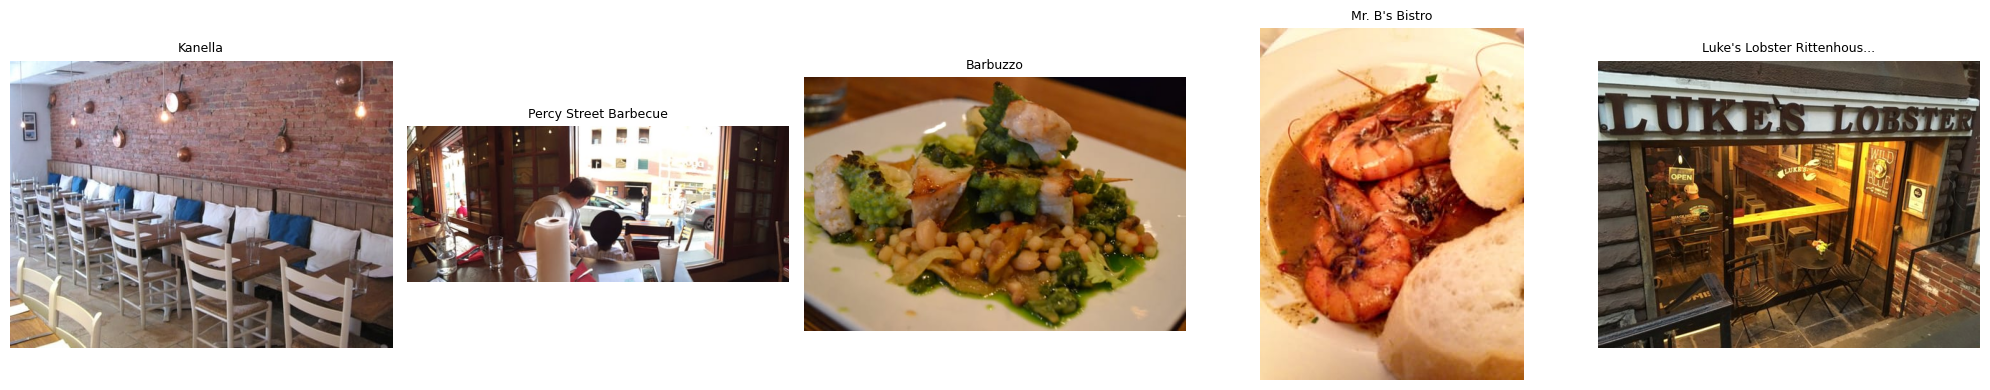


Usuario Qza0EVW1J_k0u8BIqMRbHQ  |  9 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Modo Mio - "I wish I could eat here every night. We tried Modo Mio on a Sunday night for their set priced family style dinner. We made reservations (the place isn't huge so..."
  [5*] Little Nonna's - "SOOOOOOOO good. I usually like pretty classic Italian dishes and Little Nona's has a smaller menu but everything is really a level up.   My one piece of advice ..."
  [4*] Townsend - "We came here for our anniversary dinner and had a lovely table upstairs near the window. They even wrote "Happy Anniversary" on the menu, which was a nice touch..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Luke's Lobster Rittenhouse (Philadelphia) - 4.5* - Sandwiches, Seafood, Restaurants
  2. Loco Pez (Philadelphia) - 4.0* - Restaurants, Tacos, Bars, Nightlife, Mexican
  3. Harp & Crow

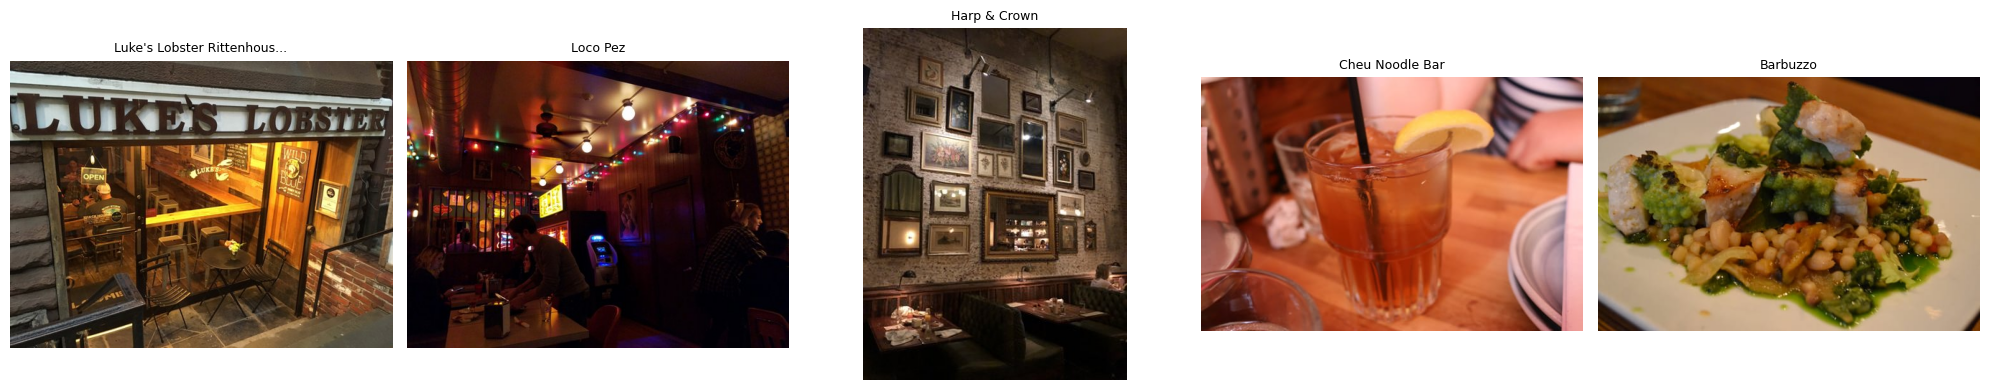


Usuario dt2VNqnnGdnYKor3uHkdlQ  |  8 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Petite Chou Bistro and Champagne Bar - "Love it!  So far our favorite brunch spot in Broad Ripple.  The atmosphere and outdoor seating are great and the ingredients and food are top notch.  I've had t..."
  [5*] Public Greens - "Yum!  Great location just off the Monon with a cute patio and long fire pit for cooler nights.  The menu is constantly changing based on local ingredients (many..."
  [5*] Milktooth - "Loved our first visit. Hour wait around noon on a Saturday in January. We ran a quick errand and then enjoyed some coffees outside while waiting (warm Jan. day ..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Delicia (Indianapolis) - 4.5* - Latin American, Caribbean, Breakfast & Brunch, Restaurants, ...
  2. The Cake Bake Shop by Gwendolyn Rogers-Broad Ripple Vi

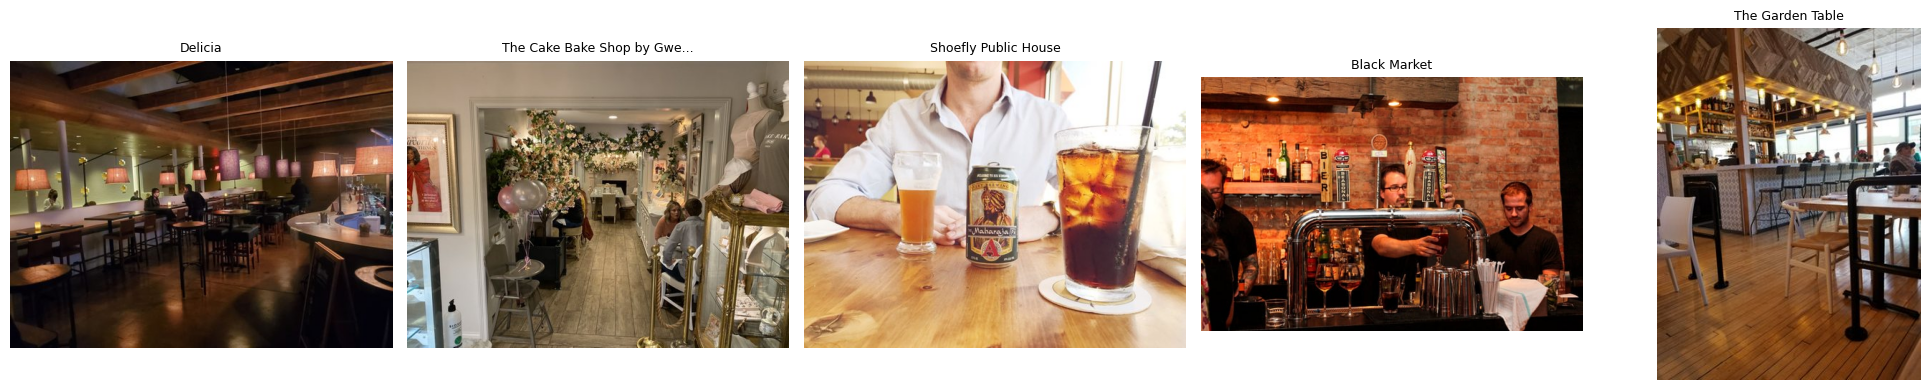


Usuario 4dwFGklOPRts-Tz2CSQZ9A  |  4 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Brocato's Sandwich Shop - "OMG this place is outrageous! If you plan on trying for the first time, plan on coming back in a week to fulfill your new addiction.   Very famous for Deviled C..."
  [5*] West Tampa Sandwich Shop - "Holy Cow! This was my very first time here and I can't believe I've waited this long!!   I had the Cuban with a ropa vieja empanada and both were unbelievably g..."
  [5*] Lee Roy Selmon's Restaurant - "The reliable Lee Roy Selmons, gotta love it! Decisions,decisions, decisions..... this is always the problem when eating here..  I really enjoy this place... I n..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Saigon Deli (Tampa) - 4.5* - Vietnamese, Delis, Soup, Coffee & Tea, Food, Restaurants
  2. Ella's Americana Folk Art Cafe (Tampa) - 4.0* - 

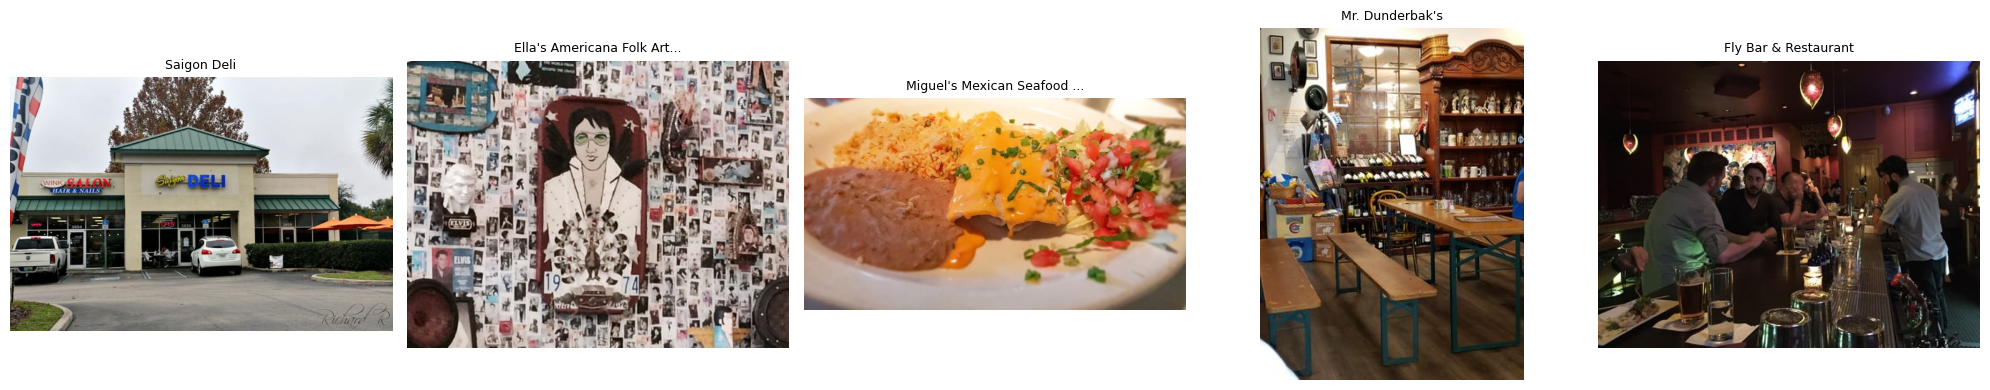


Usuario QdE2T1VEoc-QgNWKTMMixA  |  10 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Napolese Pizzeria - "Delicious pizza and a nice atmosphere. Their Paloma's were amazing and the service was great-- attentive without hovering."
  [5*] HopCat - Broad Ripple - "Two words: crack fries. They can't be beat. Hopcat boasts an impressive beer selection and they rotate regularly so there is always something new to try. It's a..."
  [5*] Quills Coffee - "Was downtown while my car was getting maintenance and needed a place to hang out. Found quills which is tucked back a bit on a side street and loved the cozy at..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Twenty Tap (Indianapolis) - 4.5* - American (New), Nightlife, Restaurants, Bars, Gastropubs, Lo...
  2. The Cake Bake Shop by Gwendolyn Rogers-Broad Ripple Village (Indianapolis) - 4.0* - Restaurants, B

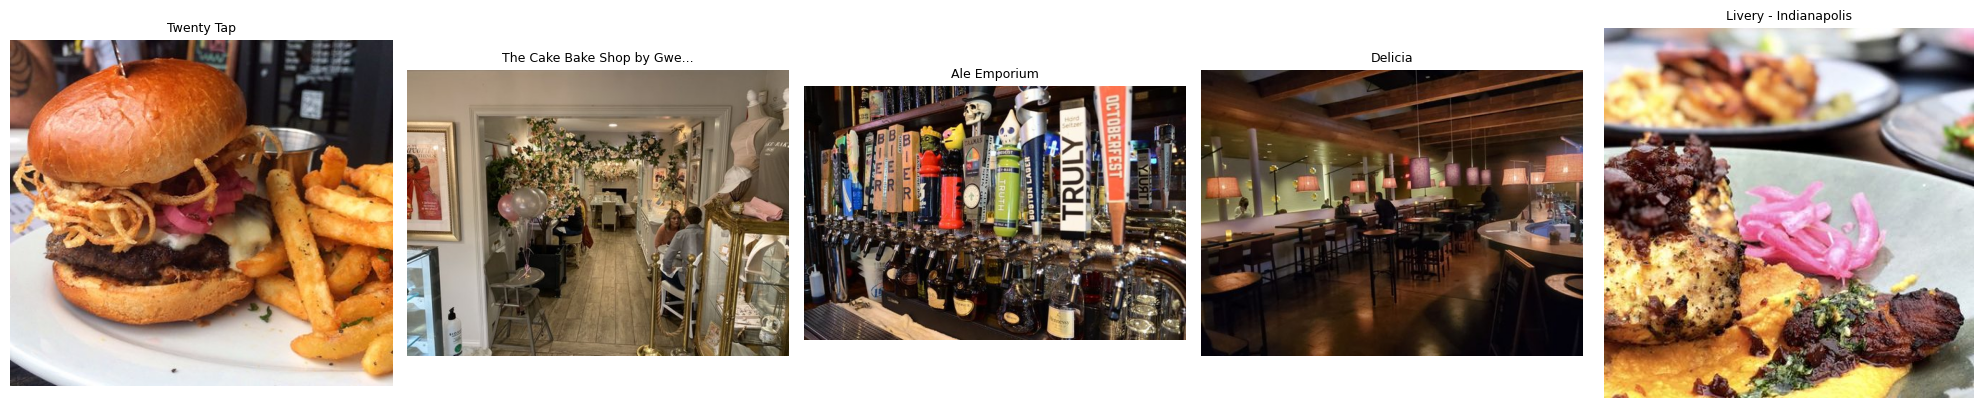

In [6]:
# 5 usuarios fijos por seed (mismos en todos los notebooks)
import pandas as pd
from src.examples import pick_sample_users, show_user_recommendations

restaurants_meta = pd.read_csv('../data/processed/restaurants.csv')
try:
    photos_meta = pd.read_csv('../data/processed/photos.csv')
except FileNotFoundError:
    photos_meta = None

sample_users = pick_sample_users(train_reviews, n=5, seed=42)
print('Usuarios de ejemplo:', sample_users)

for uid in sample_users:
    show_user_recommendations(
        uid,
        lambda u, top_k: model.recommend(u, train_reviews, top_k),
        train_reviews, restaurants_meta, photos=photos_meta,
        top_k=5, show_images=True,
    )